## - Import Library

In [ ]:
# 데이터는 아래 링크에서 다운로드하실 수 있습니다.
# https://drive.google.com/drive/folders/15yEkZFabzdtqWxwFWf5wrasNy-hIYiff?usp=drive_link

In [2]:
# 기본 라이브러리 Import
import os
import numpy as np
import torch
from PIL import Image, ImageDraw
import torch.utils.data
from typing import List, Dict, Any, Optional, Tuple

# Torchvision 관련 라이브러리 Import
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.transforms import v2 as T # 최신 v2 transform 사용
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights

- Dataset download: https://www.kaggle.com/datasets/smeschke/pedestrian-dataset
- vision code ref: https://github.com/pytorch/vision

## - Create the training Pedestrian Dataset

In [3]:
# 학습 및 평가용 헬퍼 클래스 및 함수

import time
from collections import defaultdict, deque
import datetime

# MetricLogger: 학습 중 각종 평가지표를 추적하고 출력하는 클래스
class MetricLogger(object):
    def __init__(self, delimiter="\t"):
        self.meters = defaultdict(SmoothedValue)
        self.delimiter = delimiter

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if isinstance(v, torch.Tensor):
                v = v.item()
            assert isinstance(v, (float, int))
            self.meters[k].update(v)

    def __getattr__(self, attr):
        if attr in self.meters:
            return self.meters[attr]
        if attr in self.__dict__:
            return self.__dict__[attr]
        raise AttributeError("'{}' object has no attribute '{}'".format(
            type(self).__name__, attr))

    def __str__(self):
        loss_str = []
        for name, meter in self.meters.items():
            loss_str.append(
                "{}: {}".format(name, str(meter))
            )
        return self.delimiter.join(loss_str)

    def add_meter(self, name, meter):
        self.meters[name] = meter

    def log_every(self, iterable, print_freq, header=None):
        i = 0
        if not header:
            header = ''
        start_time = time.time()
        end = time.time()
        iter_time = SmoothedValue(fmt='{avg:.4f}')
        data_time = SmoothedValue(fmt='{avg:.4f}')
        space_fmt = ':' + str(len(str(len(iterable)))) + 'd'
        if torch.cuda.is_available():
            log_msg = self.delimiter.join([
                header,
                '[{0' + space_fmt + '}/{1}]',
                'eta: {eta}',
                '{meters}',
                'time: {time}',
                'data: {data}',
                'max mem: {memory:.0f}'
            ])
        else:
            log_msg = self.delimiter.join([
                header,
                '[{0' + space_fmt + '}/{1}]',
                'eta: {eta}',
                '{meters}',
                'time: {time}',
                'data: {data}'
            ])
        MB = 1024.0 * 1024.0
        for obj in iterable:
            data_time.update(time.time() - end)
            yield obj
            iter_time.update(time.time() - end)
            if i % print_freq == 0 or i == len(iterable) - 1:
                eta_seconds = iter_time.global_avg * (len(iterable) - i)
                eta_string = str(datetime.timedelta(seconds=int(eta_seconds)))
                if torch.cuda.is_available():
                    print(log_msg.format(
                        i, len(iterable), eta=eta_string,
                        meters=str(self),
                        time=str(iter_time), data=str(data_time),
                        memory=torch.cuda.max_memory_allocated() / MB))
                else:
                    print(log_msg.format(
                        i, len(iterable), eta=eta_string,
                        meters=str(self),
                        time=str(iter_time), data=str(data_time)))
            i += 1
            end = time.time()
        total_time = time.time() - start_time
        total_time_str = str(datetime.timedelta(seconds=int(total_time)))
        print('{} Total time: {} ({:.4f} s / it)'.format(
            header, total_time_str, total_time / len(iterable)))

# SmoothedValue: 지표 값을 부드럽게(smoothing)하여 평균을 추적하는 클래스
class SmoothedValue(object):
    def __init__(self, window_size=20, fmt=None):
        if fmt is None:
            fmt = "{median:.4f} ({global_avg:.4f})"
        self.deque = deque(maxlen=window_size)
        self.total = 0.0
        self.count = 0
        self.fmt = fmt

    def update(self, value, n=1):
        self.deque.append(value)
        self.count += n
        self.total += value * n

    @property
    def median(self):
        d = torch.tensor(list(self.deque))
        return d.median().item()

    @property
    def avg(self):
        d = torch.tensor(list(self.deque), dtype=torch.float32)
        return d.mean().item()

    @property
    def global_avg(self):
        return self.total / self.count

    @property
    def max(self):
        return max(self.deque)

    @property
    def value(self):
        return self.deque[-1]

    def __str__(self):
        return self.fmt.format(
            median=self.median,
            avg=self.avg,
            global_avg=self.global_avg,
            max=self.max,
            value=self.value)

# collate_fn: DataLoader가 배치(batch)를 구성할 때 사용하는 함수
def collate_fn(batch):
    return tuple(zip(*batch))

## DataLoader

In [4]:
# PennFudanDataset 클래스 정의
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root: str, transforms: Optional[callable] = None):
        self.root = root
        self.transforms = transforms
        # 이미지와 마스크 파일 목록을 정렬하여 불러옵니다.
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx: int) -> Tuple[Any, Dict[str, Any]]:
        # 이미지와 마스크 파일 경로
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        
        # PIL을 사용하여 이미지와 마스크를 엽니다.
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = np.array(mask)
        
        # 마스크에서 고유한 객체 ID들을 찾습니다 (0은 배경).
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[1:] # 배경(0) 제외

        # 각 객체 ID에 해당하는 이진(binary) 마스크를 생성합니다.
        masks = mask == obj_ids[:, None, None]

        # 각 마스크로부터 bounding box 좌표를 계산합니다.
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        # 모든 데이터를 torch.Tensor 형태로 변환합니다.
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        # 이 데이터셋은 '보행자' 클래스 하나만 있으므로, 모든 레이블은 1입니다.
        labels = torch.ones((num_objs,), dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # 모든 인스턴스는 군중(crowd)이 아니라고 가정합니다.
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # 모델이 요구하는 형식의 target 딕셔너리를 생성합니다.
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        # transforms가 있다면 이미지와 타겟에 모두 적용합니다.
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        
        return img, target

    def __len__(self):
        return len(self.imgs)

## Mask R-CNN Model Load

In [5]:
# Mask R-CNN 모델 생성 함수
def get_model_instance_segmentation(num_classes: int):
    # COCO로 사전 학습된 Mask R-CNN 모델을 불러옵니다.
    # weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT는 가장 좋은 성능의 가중치를 사용하겠다는 의미입니다.
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)

    # Box 예측기의 입력 피쳐 수를 가져옵니다.
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # 사전 학습된 예측기를 새로운 예측기로 교체합니다.
    # 출력 노드 수는 우리가 정의한 클래스 수(num_classes)와 같습니다.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Mask 예측기의 입력 피쳐 수를 가져옵니다.
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # Mask 예측기를 새로운 예측기로 교체합니다.
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model

## Image Transform

In [6]:
# 데이터 변환 함수 정의
def get_transform(train: bool):
    transforms = []
    # 이미지를 PIL에서 Tensor로 변환하고, 0-1 범위로 정규화합니다.
    transforms.append(T.ToImage())
    transforms.append(T.ToDtype(torch.float32, scale=True))
    
    if train:
        # 학습 시에만 50% 확률로 좌우 반전을 적용합니다.
        transforms.append(T.RandomHorizontalFlip(0.5))
        
    return T.Compose(transforms)

## Load pretrained Mask R-CNN

- maskrcnn_resnet50_fpn: https://pytorch.org/vision/main/models/generated/torchvision.models.detection.maskrcnn_resnet50_fpn.html#torchvision.models.detection.maskrcnn_resnet50_fpn

In [7]:
# 셀 9: 데이터셋, DataLoader 생성 및 분할
# 데이터셋 루트 디렉토리
root = 'data'

# use our dataset and defined transformations
dataset = PennFudanDataset(root, get_transform(train=True))
dataset_test = PennFudanDataset(root, get_transform(train=False))

# split the dataset in train and test set
# torch.manual_seed(1) # 재현성을 위해 시드 고정
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, num_workers=2,
    collate_fn=collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=2,
    collate_fn=collate_fn)

print(f"학습 데이터: {len(dataset)}개 / 테스트 데이터: {len(dataset_test)}개")

학습 데이터: 120개 / 테스트 데이터: 50개


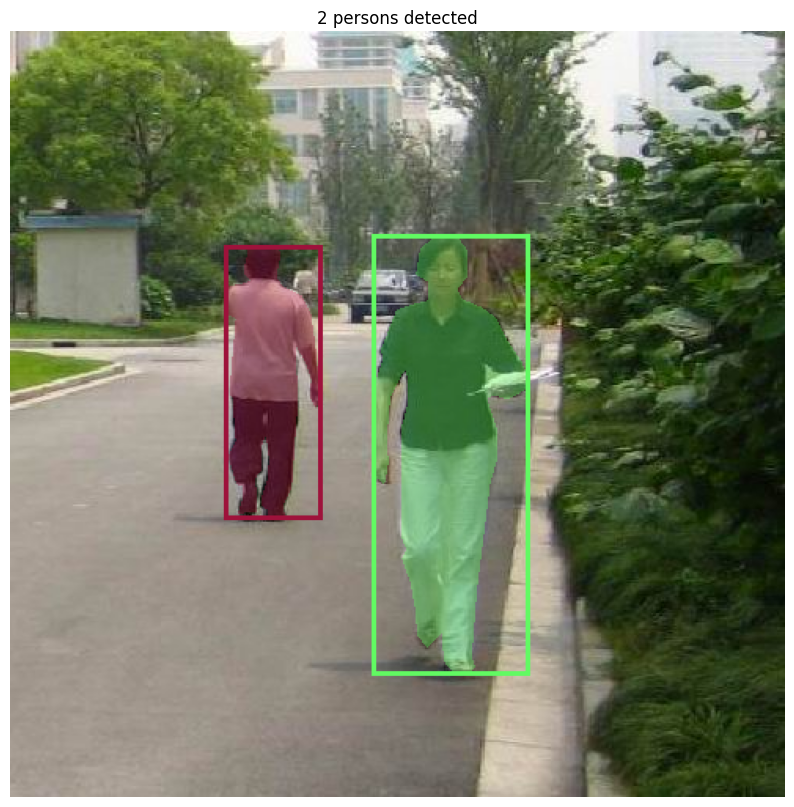

In [8]:
import matplotlib.pyplot as plt
import random

# 시각화를 위해 transform이 없는 원본 데이터셋을 하나 더 생성합니다.
# ToTensor만 적용하여 이미지를 확인합니다.
vis_dataset = PennFudanDataset(root, transforms=T.ToImage())

# 랜덤으로 샘플 하나 선택
idx = random.randint(0, len(vis_dataset) - 1)
img_tensor, target = vis_dataset[idx]

# Tensor를 시각화를 위한 PIL Image로 변환
img_pil = T.ToPILImage()(img_tensor)

# 시각화를 위한 색상 랜덤 생성
colors = [[random.randint(0, 255) for _ in range(3)] for _ in range(len(target["boxes"]))]

# 원본 이미지 위에 Bounding Box와 Mask 그리기
draw = ImageDraw.Draw(img_pil)
for i, (box, mask) in enumerate(zip(target["boxes"], target["masks"])):
    # Bounding Box 그리기
    box = box.tolist()
    color = tuple(colors[i])
    draw.rectangle(box, outline=color, width=3)
    
    # Mask를 RGBA 이미지로 변환하여 반투명하게 합성
    mask_np = mask.numpy()
    mask_colored = np.zeros((mask_np.shape[0], mask_np.shape[1], 4), dtype=np.uint8)
    mask_colored[mask_np > 0] = color + (100,) # 색상과 투명도(alpha) 설정
    
    mask_pil = Image.fromarray(mask_colored, "RGBA")
    img_pil.paste(mask_pil, (0,0), mask_pil)


# 결과 이미지 출력
plt.figure(figsize=(10, 10))
plt.imshow(img_pil)
plt.axis('off')
plt.title(f"{len(target['boxes'])} persons detected")
plt.show()

## - Data preprocessing

In [9]:
# 데이터 변환 함수 정의
def get_transform(train: bool):
    transforms = []
    # 이미지를 PIL에서 Tensor로 변환하고, 0-1 범위로 정규화합니다.
    transforms.append(T.ToImage())
    transforms.append(T.ToDtype(torch.float32, scale=True))
    
    if train:
        # 학습 시에만 50% 확률로 좌우 반전을 적용합니다.
        transforms.append(T.RandomHorizontalFlip(0.5))
        
    return T.Compose(transforms)

## Fine-tune Mask R-CNN

In [10]:
# 셀 10 (수정된 코드): 학습 및 평가 루프 함수 정의

@torch.inference_mode()
def evaluate(model, data_loader, device):
    n_threads = torch.get_num_threads()
    torch.set_num_threads(1)
    cpu_device = torch.device("cpu")
    model.eval()
    metric_logger = MetricLogger(delimiter="  ")
    header = "Test:"

    # COCO 평가를 위한 준비
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
    
    # 임시 COCO gt 생성
    gt_coco = COCO()
    gt_coco.dataset = {
        'info': {},
        'images': [], 
        'annotations': [], 
        'categories': [{'id': 1, 'name': 'person'}]
    }
    img_id = 0
    ann_id = 0
    
    results = []

    for images, targets in metric_logger.log_every(data_loader, 100, header=header):
        images = list(img.to(device) for img in images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        model_time = time.time()
        outputs = model(images)

        outputs = [{k: v.to(cpu_device) for k, v in t.items()} for t in outputs]
        model_time = time.time() - model_time

        # COCO 결과 형식으로 변환
        for i, (output, target) in enumerate(zip(outputs, targets)):
            image_id = target["image_id"].item()
            
            # GT 데이터 추가
            if not any(d['id'] == image_id for d in gt_coco.dataset['images']):
                 gt_coco.dataset['images'].append({'id': image_id, 'height': images[i].shape[1], 'width': images[i].shape[2]})
            
            for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
                 results.append({
                    "image_id": image_id,
                    "category_id": label.item(),
                    "bbox": [box[0].item(), box[1].item(), (box[2] - box[0]).item(), (box[3] - box[1]).item()],
                    "score": score.item(),
                })
            
            # GT 어노테이션 추가
            for box, label in zip(target['boxes'], target['labels']):
                gt_coco.dataset['annotations'].append({
                    'id': ann_id,
                    'image_id': image_id,
                    'category_id': label.item(),
                    'bbox': [box[0].item(), box[1].item(), (box[2] - box[0]).item(), (box[3] - box[1]).item()],
                    'area': ((box[2] - box[0]) * (box[3] - box[1])).item(),
                    'iscrowd': 0
                })
                ann_id += 1

    gt_coco.createIndex()
    pred_coco = gt_coco.loadRes(results)

    coco_eval = COCOeval(gt_coco, pred_coco, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    
    torch.set_num_threads(n_threads)
    return coco_eval


def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq):
    model.train()
    metric_logger = MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", SmoothedValue(window_size=1, fmt="{value:.6f}"))
    header = f"Epoch: [{epoch}]"

    for images, targets in metric_logger.log_every(data_loader, print_freq, header):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # reduce losses over all GPUs for logging purposes
        loss_dict_reduced = {k: v.item() for k, v in loss_dict.items()}
        losses_reduced = sum(loss for loss in loss_dict_reduced.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        metric_logger.update(loss=losses_reduced, **loss_dict_reduced)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])

    return metric_logger

In [ ]:
# 실제 학습 실행
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'사용 디바이스: {device}')

# 클래스 수 (배경 + 보행자)
num_classes = 2

# 모델, 옵티마이저, 스케줄러 설정
model = get_model_instance_segmentation(num_classes)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# 학습 에폭 수
num_epochs = 10

for epoch in range(num_epochs):
    # 1 에폭 학습 및 10번마다 로그 출력
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    
    # 학습률 업데이트
    lr_scheduler.step()

print("학습이 완료되었습니다.")

사용 디바이스: cuda


Epoch: [0]  [ 0/60]  eta: 0:01:06  lr: 0.005000  loss: 3.6128 (3.6128)  loss_classifier: 0.7619 (0.7619)  loss_box_reg: 0.3521 (0.3521)  loss_mask: 2.4808 (2.4808)  loss_objectness: 0.0104 (0.0104)  loss_rpn_box_reg: 0.0076 (0.0076)  time: 1.1089  data: 0.1818  max mem: 2266
Epoch: [0]  [10/60]  eta: 0:00:11  lr: 0.005000  loss: 1.1561 (1.3798)  loss_classifier: 0.1882 (0.2622)  loss_box_reg: 0.2438 (0.2392)  loss_mask: 0.6840 (0.8313)  loss_objectness: 0.0335 (0.0351)  loss_rpn_box_reg: 0.0090 (0.0121)  time: 0.2383  data: 0.0230  max mem: 2430
Epoch: [0]  [20/60]  eta: 0:00:07  lr: 0.005000  loss: 1.0076 (1.1830)  loss_classifier: 0.1342 (0.1994)  loss_box_reg: 0.1845 (0.2095)  loss_mask: 0.5916 (0.7186)  loss_objectness: 0.0232 (0.0407)  loss_rpn_box_reg: 0.0097 (0.0148)  time: 0.1429  data: 0.0075  max mem: 2430
Epoch: [0]  [30/60]  eta: 0:00:05  lr: 0.005000  loss: 0.8486 (1.0470)  loss_classifier: 0.0928 (0.1645)  loss_box_reg: 0.1534 (0.1866)  loss_mask: 0.5488 (0.6480)  loss_ob

In [13]:
# 최종 모델 평가
evaluate(model, data_loader_test, device=device)

Test:  [ 0/50]  eta: 0:00:09    time: 0.1989  data: 0.1311  max mem: 2979
Test:  [49/50]  eta: 0:00:00    time: 0.0404  data: 0.0022  max mem: 2979
Test: Total time: 0:00:02 (0.0433 s / it)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.789
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.971
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.969
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.436
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.804
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.357
 Ave

## Evaluate and Analyze Trained Data

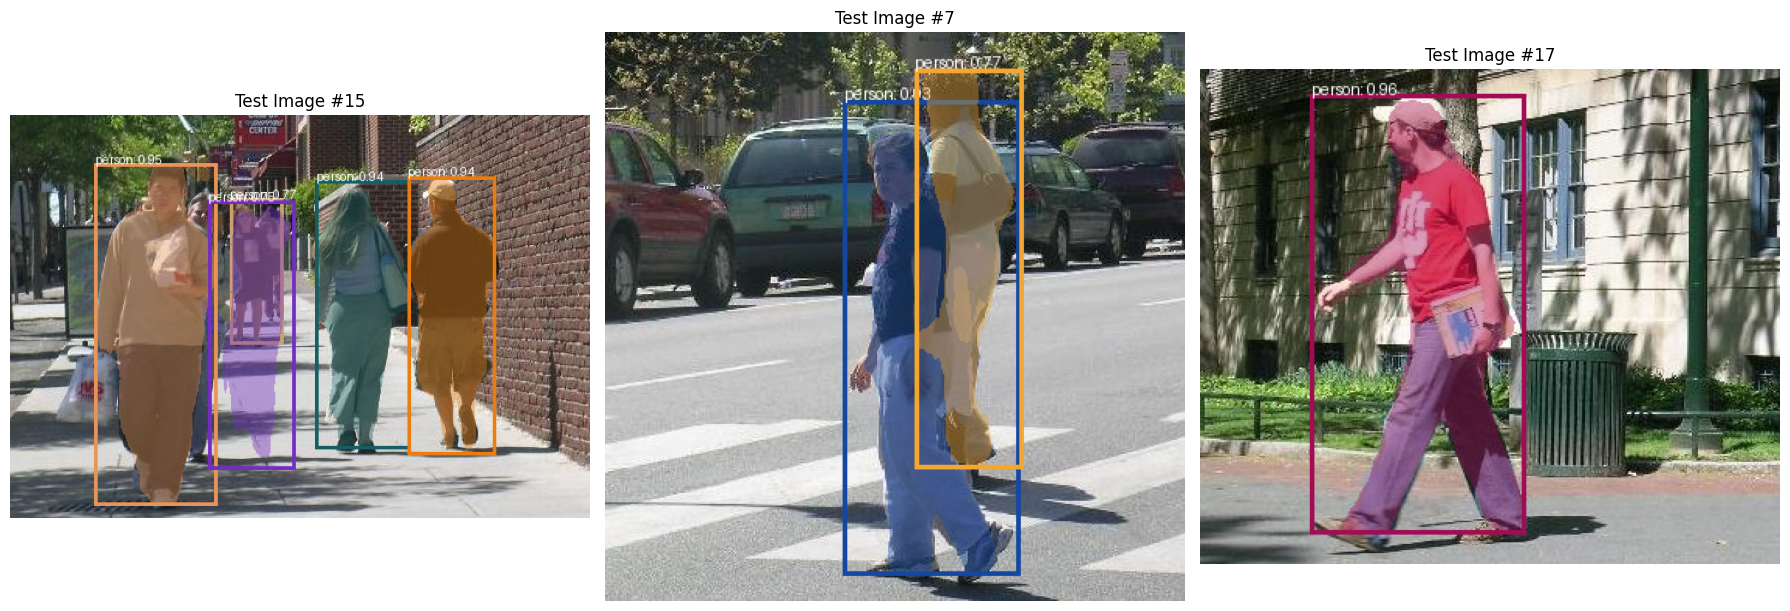

In [14]:
# 상세 결과 시각화 함수
import matplotlib.pyplot as plt
import random

def visualize_prediction(model, dataset, device, num_images=5, threshold=0.7):
    model.eval()
    
    # 랜덤하게 N개의 이미지를 선택
    indices = random.sample(range(len(dataset)), num_images)
    
    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 6, 6))
    if num_images == 1:
        axes = [axes]
        
    for i, ax in enumerate(axes):
        img_tensor, _ = dataset[indices[i]]
        
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])
        
        img_pil = T.ToPILImage()(img_tensor.cpu())
        draw = ImageDraw.Draw(img_pil)
        
        predictions = prediction[0]
        for j, (box, label, score, mask) in enumerate(zip(predictions['boxes'], predictions['labels'], predictions['scores'], predictions['masks'])):
            if score > threshold:
                color = tuple(np.random.randint(0, 255, 3))
                
                box = box.cpu().numpy()
                draw.rectangle(box, outline=color, width=3)
                
                label_text = f"person: {score:.2f}"
                draw.text((box[0], box[1] - 10), label_text, fill="white")

                # 1. 모델 예측 마스크를 가져옵니다.
                mask_np = mask.cpu().numpy().squeeze()
                
                # 2. 마스크와 동일한 크기의 RGBA 컬러 마스크를 새로 만듭니다. (배경은 투명)
                mask_colored = np.zeros((mask_np.shape[0], mask_np.shape[1], 4), dtype=np.uint8)
                
                # 3. 예측된 영역(mask > 0.5)에만 색상과 투명도를 적용합니다.
                mask_colored[mask_np > 0.5] = color + (100,) # color + alpha
                
                # 4. NumPy 배열을 PIL 이미지로 변환합니다.
                mask_pil = Image.fromarray(mask_colored, "RGBA")
                
                # 5. 원본 이미지에 컬러 마스크를 합성합니다.
                #    붙여넣을 이미지(mask_pil)와 마스크(mask_pil)를 동일하게 사용합니다.
                img_pil.paste(mask_pil, (0, 0), mask_pil)

        ax.imshow(img_pil)
        ax.axis('off')
        ax.set_title(f"Test Image #{indices[i]}")
        
    plt.tight_layout()
    plt.show()

# 함수 실행 (테스트 데이터셋 사용)
visualize_prediction(model, dataset_test, device, num_images=3, threshold=0.7)

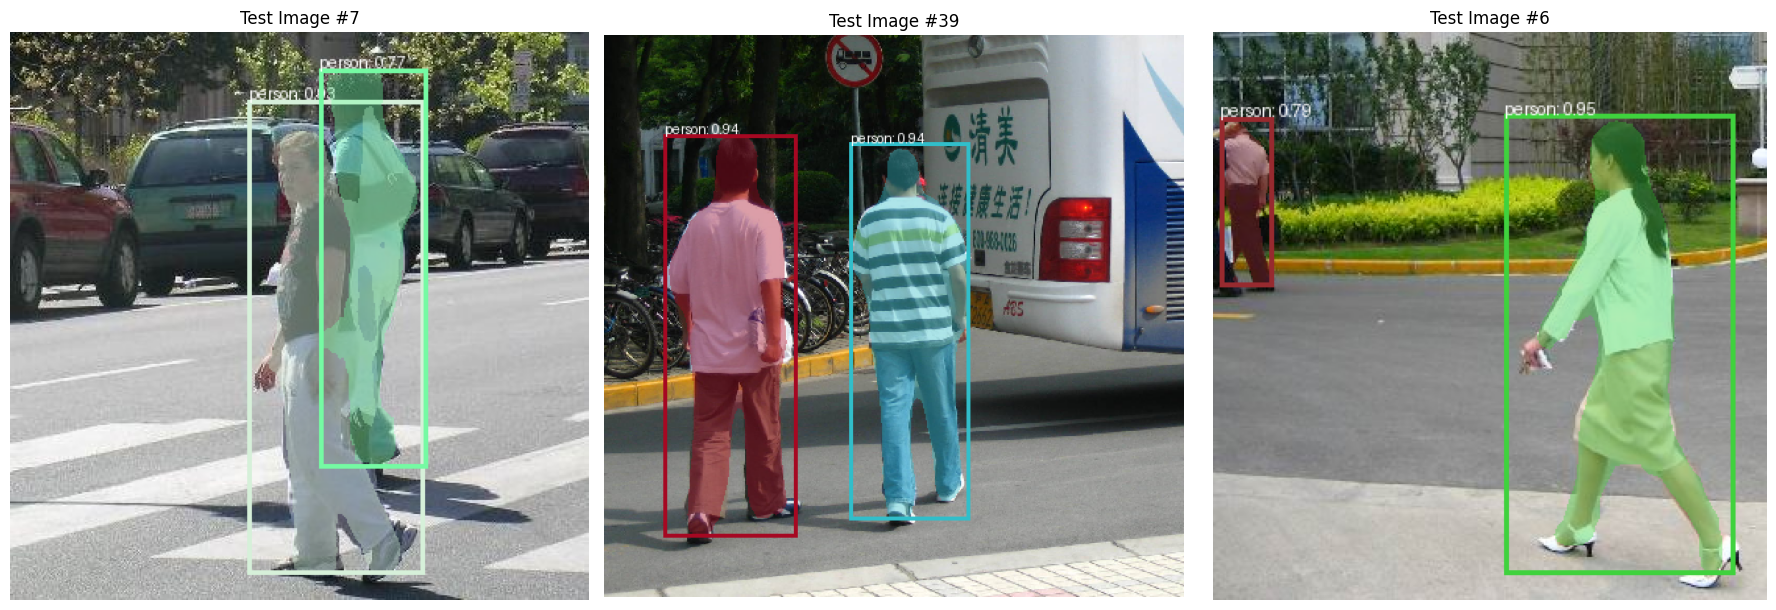

In [16]:
visualize_prediction(model, dataset_test, device, num_images=3, threshold=0.7)

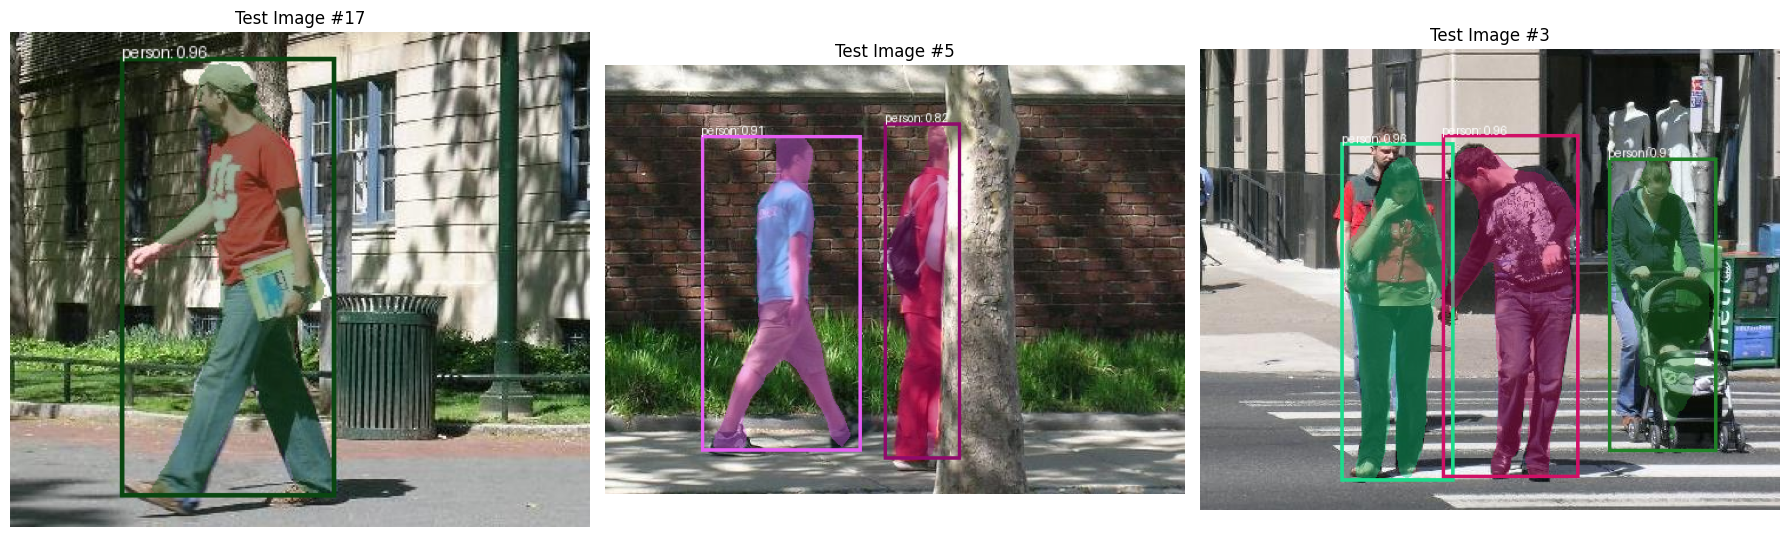

In [17]:
visualize_prediction(model, dataset_test, device, num_images=3, threshold=0.7)